In [1]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/transmittance.yaml')
import logging
# deactivate logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

In [2]:
N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2022-04-01', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [0.0] * N_timesteps),
        'longitude' : ('time', [0.0] * N_timesteps),
        'altitude' : ('altitude', [0.0]),
    },
    data_vars={
        'albedo' : ('time' , [0.5] * N_timesteps),
    }
)

ds = ds.isel(time=[12])

In [3]:


# Run a spectral simulation for a single point
print("Running single point spectral simulation...")
ds = ds.pyradtran.run_uvspec(
    config_path=config_path,
    albedo_var='albedo',
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete!")

2025-05-07 17:45:48,906 - pyradtran.interface - INFO - Overriding configuration altitude with 1 levels from dataset: [0.]
2025-05-07 17:45:48,907 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250507_174548.nc
2025-05-07 17:45:48,907 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250507_174548.nc
2025-05-07 17:45:48,908 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-07 17:45:48,908 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-07 17:45:48,918 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.
2025-05-07 17:45:48,921 - pyradtran.interface - INFO - Running 1 simulations across time/location points...
2025-05-07 17:45:48,918 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.
2025-05-07 17:45:48,92

Running single point spectral simulation...


2025-05-07 17:45:48,943 - pyradtran.core - DEBUG - Time 2022-04-01 12:00:00 -> Closest Sonde: 20220401_42952SOD.dat
2025-05-07 17:45:48,949 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220401_120000_k5i5lf7k.inp
2025-05-07 17:45:48,950 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20220401_120000_k5i5lf7k.inp > uvspec_20220401_120000_k5i5lf7k.out
2025-05-07 17:45:48,949 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220401_120000_k5i5lf7k.inp
2025-05-07 17:45:48,950 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20220401_120000_k5i5lf7k.inp > uvspec_20220401_120000_k5i5lf7k.out
2025-05-07 17:45:51,471 - pyradtran.core - DEBUG - uvspec finished successfully for uvspec_20220401_120000_k5i5lf7k.inp.
2025-05-07 17:45:51,474 -


Simulation complete!


In [11]:
ds

<xarray.Dataset> Size: 19kB
Dimensions:     (time: 1, wavelength: 301)
Coordinates:
    latitude    (time) float64 8B 0.0
    longitude   (time) float64 8B 0.0
  * time        (time) datetime64[ns] 8B 2022-04-01T12:00:00
  * wavelength  (wavelength) float64 2kB 400.0 401.0 402.0 ... 698.0 699.0 700.0
Data variables:
    sza         (time, wavelength) float64 2kB 4.743 4.743 4.743 ... 4.743 4.743
    edir        (time, wavelength) float64 2kB 1.205e+03 1.239e+03 ... 1.323e+03
    eglo        (time, wavelength) float64 2kB 1.654e+03 1.696e+03 ... 1.368e+03
    edn         (time, wavelength) float64 2kB 448.9 456.3 476.4 ... 45.53 44.95
    eup         (time, wavelength) float64 2kB 827.1 847.8 892.4 ... 691.1 683.8
    enet        (time, wavelength) float64 2kB 827.1 847.8 892.4 ... 691.1 683.8
    albedo      (time, wavelength) float64 2kB 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5
Attributes:
    generated_by:      pyradtran
    wavelength_range:  400.0 to 700.0 nm

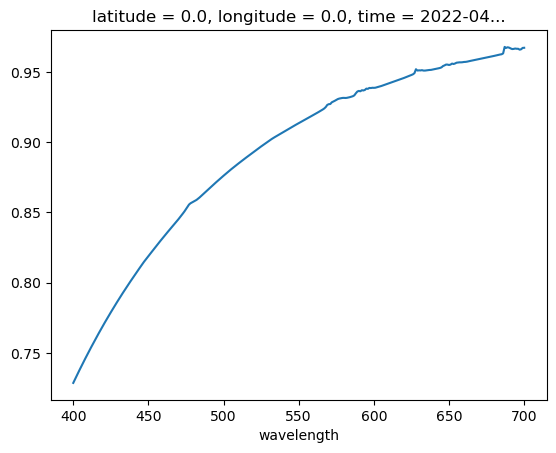

In [12]:
(ds['edir'] / ds['eglo']).plot()

In [13]:
import pandas as pd

ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2508668/941015400.py:3: SyntaxWarning: invalid escape sequence '\s'
  ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()


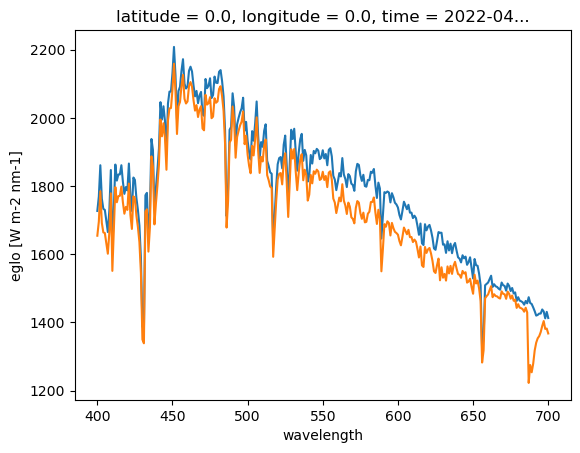

In [14]:
ds_e0.sel(wavelength=ds.wavelength).flux.plot()
ds['eglo'].sel(wavelength=ds.wavelength).plot()


In [15]:
# integrate over the wavelength range
ds_glo_integrated = ds['edir'].sel(wavelength=ds.wavelength).integrate('wavelength').values
ds_e0_integrated = ds_e0.sel(wavelength=ds.wavelength).flux.integrate('wavelength').values

print(ds_glo_integrated / ds_e0_integrated)

[0.85979914]


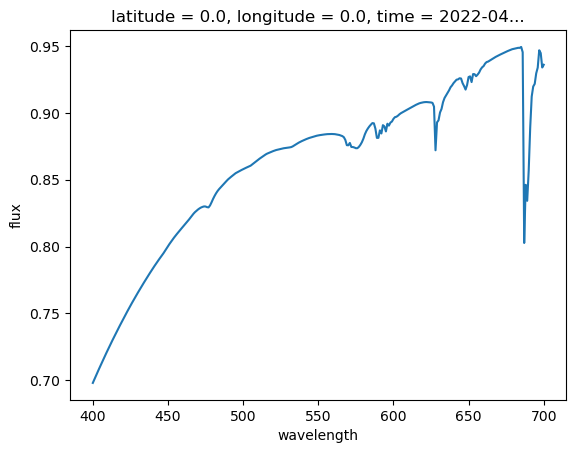

In [16]:
(ds['edir'] / ds_e0.sel(wavelength=ds.wavelength)).flux.plot()

In [17]:
bbr_halo = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO.nc')


In [ ]:
bbr_resample = bbr_halo.